# Base Line Models

## Importing Engineered Features

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('engineered_features.csv')
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,is_weekend,account_age_bucket,amount_bucket,ip_risk_score_bucket,device_trust_score_bucket,night_hours,account_age_breakdown,amount_breakdown,ip_risk,device_risk
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0,91-365 days,100-500,<0.3,0.5-0.7,0,matured,low,low,medium
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0,>365 days,100-500,0.5-0.7,0.3-0.5,0,matured,low,medium,medium
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0,>365 days,100-500,0.3-0.5,>0.8,0,matured,low,medium,high
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0,91-365 days,<100,0.5-0.7,0.5-0.7,0,matured,low,medium,medium
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0,91-365 days,100-500,<0.3,>0.8,0,matured,low,low,high


In [3]:
df.isna().sum()

,0
transaction_id,0
customer_id,0
timestamp,0
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,0
fee,0


In [4]:
print(df['timestamp'].dtype)

object


In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

## More Engineered Features

In [6]:
df['is_high_velocity_1h'] = (df['txn_velocity_1h'] < 4).astype(int)

In [7]:
df['is_high_velocity_24h'] = (df['txn_velocity_24h'] < 4).astype(int)

## Creating Train and Test Dataset

In [8]:
print(df['timestamp'].dtype)

datetime64[ns, UTC]


In [9]:
df.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'home_country_cleaned',
       'hour', 'day_of_week', 'month', 'is_weekend', 'account_age_bucket',
       'amount_bucket', 'ip_risk_score_bucket', 'device_trust_score_bucket',
       'night_hours', 'account_age_breakdown', 'amount_breakdown', 'ip_risk',
       'device_risk', 'is_high_velocity_1h', 'is_high_velocity_24h'],
      dtype='object')

In [10]:
df = df.sort_values(by='timestamp').reset_index(drop=True)

In [11]:
columns_to_drop = ['transaction_id',
                   'timestamp',
                   'customer_id',
                   'exchange_rate_src_to_dest',
                   'device_id',
                   'ip_risk_score',
                   'txn_velocity_1h',
                   'txn_velocity_24h',
                   'account_age_days',
                   ]
df.drop(columns=columns_to_drop, inplace=True)

In [12]:
all_features = df.columns.tolist()
all_features.remove('is_fraud')
all_features

['home_country',
 'source_currency',
 'dest_currency',
 'channel',
 'amount_src',
 'amount_usd',
 'fee',
 'new_device',
 'ip_address',
 'ip_country',
 'location_mismatch',
 'kyc_tier',
 'device_trust_score',
 'chargeback_history_count',
 'risk_score_internal',
 'corridor_risk',
 'home_country_cleaned',
 'hour',
 'day_of_week',
 'month',
 'is_weekend',
 'account_age_bucket',
 'amount_bucket',
 'ip_risk_score_bucket',
 'device_trust_score_bucket',
 'night_hours',
 'account_age_breakdown',
 'amount_breakdown',
 'ip_risk',
 'device_risk',
 'is_high_velocity_1h',
 'is_high_velocity_24h']

In [13]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"Train: {len(train_df)} rows {(train_df['is_fraud']).sum()} fraud, {(train_df['is_fraud']).mean():.3f} rate of fraud")
print(f"Test: {len(test_df)} rows {(test_df['is_fraud']).sum()} fraud, {(test_df['is_fraud']).mean():.3f} rate of fraud")

Train: 8605 rows 675 fraud, 0.078 rate of fraud
Test: 2152 rows 307 fraud, 0.143 rate of fraud


In [14]:
X_train = train_df[all_features]
y_train = train_df['is_fraud']

X_test = test_df[all_features]
y_test = test_df['is_fraud']

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (8605, 32), y_train: (8605,)
X_test: (2152, 32), y_test: (2152,)


## Hot Encoding and Standard Scaling

In [15]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [16]:
numerical_features.remove('is_fraud')

In [17]:
len(categorical_features) + len(numerical_features)

30

In [18]:
remaining_features = list(
    set(all_features) - set(categorical_features) - set(numerical_features)
)
remaining_features

['location_mismatch', 'new_device']

In [19]:
print(df['location_mismatch'].dtype)

bool


In [20]:
boolean_features = ['location_mismatch', 'new_device']

In [21]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('bool', 'passthrough', boolean_features)
    ])


X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print(f"X_train_preprocessed: {X_train_preprocessed.shape}")
print(f"Original features: {len(all_features)}, After encoding: {X_train_preprocessed.shape[1]}")


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


X_train_preprocessed: (8605, 8522)
Original features: 32, After encoding: 8522


In [23]:
df.isna().sum()

,0
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,0
fee,0
new_device,0
ip_address,0
ip_country,0


## Training Baseline Models

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_preprocessed, y_train)

y_pred_lr = lr_model.predict(X_test_preprocessed)
y_proba_lr = lr_model.predict_proba(X_test_preprocessed)[:, 1]

print("Logistic Regression Results:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print(f"\nROC AUC Score:, {roc_auc_score(y_test, y_proba_lr):.2f}")

Logistic Regression Results:

Confusion Matrix:
[[1829   16]
 [  19  288]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1845
           1       0.95      0.94      0.94       307

    accuracy                           0.98      2152
   macro avg       0.97      0.96      0.97      2152
weighted avg       0.98      0.98      0.98      2152


ROC AUC Score:, 0.98


In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.25, 0.4, 0.6, 0.65, 0.8]



In [26]:
for t in thresholds:
    y_pred_t = (y_proba_lr >= t).astype(int)
    print(f"Threshold: {t}")
    print(
        classification_report(y_test, y_pred_t)
    )

Threshold: 0.1
              precision    recall  f1-score   support

           0       0.99      0.74      0.85      1845
           1       0.39      0.98      0.55       307

    accuracy                           0.77      2152
   macro avg       0.69      0.86      0.70      2152
weighted avg       0.91      0.77      0.81      2152

Threshold: 0.25
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1845
           1       0.69      0.95      0.80       307

    accuracy                           0.93      2152
   macro avg       0.84      0.94      0.88      2152
weighted avg       0.95      0.93      0.94      2152

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1845
           1       0.88      0.95      0.91       307

    accuracy                           0.97      2152
   macro avg       0.94      0.96      0.95      2152
weighted avg       0.98     

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    max_depth=10,
    class_weight='balanced',
    n_estimators=100,
    random_state=42,
    n_jobs=1
    )
rf_model.fit(X_train_preprocessed, y_train)

#Predict on test
y_pred_rf = rf_model.predict(X_test_preprocessed)
y_proba_rf = rf_model.predict_proba(X_test_preprocessed)[:, 1]

#Evaluation
print("Random Forest Results:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print(f"\nROC AUC Score:, {roc_auc_score(y_test, y_proba_rf):.2f}")

Random Forest Results:

Confusion Matrix:
[[1843    2]
 [  24  283]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       0.99      0.92      0.96       307

    accuracy                           0.99      2152
   macro avg       0.99      0.96      0.97      2152
weighted avg       0.99      0.99      0.99      2152


ROC AUC Score:, 0.98


In [28]:
for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    print(f"Threshold: {t}")
    print(
        classification_report(y_test, y_pred_t)
    )

Threshold: 0.1
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1845
           1       0.14      1.00      0.25       307

    accuracy                           0.14      2152
   macro avg       0.07      0.50      0.12      2152
weighted avg       0.02      0.14      0.04      2152

Threshold: 0.25
              precision    recall  f1-score   support

           0       0.99      0.63      0.77      1845
           1       0.31      0.98      0.47       307

    accuracy                           0.68      2152
   macro avg       0.65      0.81      0.62      2152
weighted avg       0.90      0.68      0.73      2152

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1845
           1       0.83      0.94      0.88       307

    accuracy                           0.96      2152
   macro avg       0.91      0.95      0.93      2152
weighted avg       0.97     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
from xgboost import XGBClassifier

scale_pos_w = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_w,
    random_state=42,
    eval_metric='logloss'
    )

xgb_model.fit(X_train_preprocessed, y_train)

#Predict at test
y_pred_xgb = xgb_model.predict(X_test_preprocessed)
y_proba_xgb = xgb_model.predict_proba(X_test_preprocessed)[:, 1]

#Evaluation
print("XGBoost Results:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
print(f"\nROC AUC Score:, {roc_auc_score(y_test, y_proba_xgb):.2f}")

XGBoost Results:

Confusion Matrix:
[[1824   21]
 [  22  285]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1845
           1       0.93      0.93      0.93       307

    accuracy                           0.98      2152
   macro avg       0.96      0.96      0.96      2152
weighted avg       0.98      0.98      0.98      2152


ROC AUC Score:, 0.97


In [30]:
for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    print(f"Threshold: {t}")
    print(
        classification_report(y_test, y_pred_t)
    )

Threshold: 0.1
              precision    recall  f1-score   support

           0       0.99      0.74      0.85      1845
           1       0.38      0.96      0.55       307

    accuracy                           0.77      2152
   macro avg       0.69      0.85      0.70      2152
weighted avg       0.90      0.77      0.81      2152

Threshold: 0.25
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1845
           1       0.68      0.94      0.79       307

    accuracy                           0.93      2152
   macro avg       0.83      0.93      0.87      2152
weighted avg       0.94      0.93      0.93      2152

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1845
           1       0.85      0.93      0.89       307

    accuracy                           0.97      2152
   macro avg       0.92      0.95      0.93      2152
weighted avg       0.97     

In [31]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    verbosity=-1,
    random_state=42,
    )

lgbm_model.fit(X_train_preprocessed, y_train)

#Predict as test
y_pred_lgbm = lgbm_model.predict(X_test_preprocessed)
y_proba_lgbm = lgbm_model.predict_proba(X_test_preprocessed)[:, 1]

#Evaluation
print("LightGBM Results:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))
print(f"\nROC AUC Score:, {roc_auc_score(y_test, y_proba_lgbm):.2f}")

LightGBM Results:

Confusion Matrix:
[[1826   19]
 [  24  283]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1845
           1       0.94      0.92      0.93       307

    accuracy                           0.98      2152
   macro avg       0.96      0.96      0.96      2152
weighted avg       0.98      0.98      0.98      2152


ROC AUC Score:, 0.97


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [32]:
for t in thresholds:
    y_pred_t = (y_proba_lgbm >= t).astype(int)
    print(
        f"Threshold {t:.2f} | "
        f"Precision: {precision_score(y_test, y_pred_t):.3f} | "
        f"Recall: {recall_score(y_test, y_pred_t):.3f} | "
        f"F1: {f1_score(y_test, y_pred_t):.3f}"
    )

Threshold 0.10 | Precision: 0.455 | Recall: 0.945 | F1: 0.614
Threshold 0.25 | Precision: 0.748 | Recall: 0.928 | F1: 0.828
Threshold 0.40 | Precision: 0.863 | Recall: 0.925 | F1: 0.893
Threshold 0.60 | Precision: 0.969 | Recall: 0.922 | F1: 0.945
Threshold 0.65 | Precision: 0.979 | Recall: 0.922 | F1: 0.950
Threshold 0.80 | Precision: 0.993 | Recall: 0.922 | F1: 0.956


## Feature Importance and SHAP Interpretability

### Logistic Feature Importance

In [33]:
lr_coeffecients = lr_model.coef_[0]
lr_coeffecients

array([-0.30189635,  0.06787282,  0.47206758, ..., -0.24671581,
        0.95234666, -0.67180154])

In [34]:
print(len(lr_coeffecients))
print(len(all_features))


8522
32


In [35]:
cat_encoder = preprocessor.named_transformers_['cat']

cat_features = list(
    cat_encoder.get_feature_names_out(categorical_features)
)


In [36]:
encoded_features = numerical_features + cat_features + boolean_features
len(encoded_features)

8522

In [37]:
feature_importance = pd.DataFrame({
    'features': encoded_features,
    'coefficient': lr_coeffecients
})

In [38]:
feature_importance['abs_coef'] = feature_importance['coefficient'].abs()


In [39]:
feature_importance = feature_importance.sort_values(by='abs_coef', ascending=False)

In [40]:
feature_importance.head(15)


,features,coefficient,abs_coef
2976,ip_address_179.17.146.251,3.996764,3.996764
4740,ip_address_224.224.80.254,3.535297,3.535297
7191,ip_address_62.123.91.131,3.526898,3.526898
2569,ip_address_168.175.194.23,3.510534,3.510534
958,ip_address_124.240.98.190,3.468381,3.468381
1233,ip_address_131.60.43.161,3.398820,3.398820
849,ip_address_121.186.93.199,3.366773,3.366773
6647,ip_address_48.38.194.193,3.347527,3.347527
1444,ip_address_137.172.155.222,3.327389,3.327389
5191,ip_address_236.181.218.56,3.224402,3.224402


In [41]:
def get_original_feature(col):
    if col in numerical_features or col in boolean_features:
        return col

    for orig in categorical_features:
        if col.startswith(orig + '_'):
            return orig
    return col


In [42]:
feature_importance['original_feature'] = (
    feature_importance['features']
    .apply(get_original_feature)
)


In [43]:
aggregated_importance = (
    feature_importance
    .groupby('original_feature')['abs_coef']
    .sum()
    .reset_index()
    .sort_values(by='abs_coef', ascending=False)
)


In [44]:
aggregated_importance

,original_feature,abs_coef
17,ip_address,701.182340
18,ip_country,3.548164
15,home_country,2.949736
1,account_age_bucket,2.726414
10,dest_currency,2.678671
24,kyc_tier,2.491474
13,device_trust_score_bucket,2.134318
20,ip_risk_score_bucket,1.890999
3,amount_bucket,1.611648
2,amount_breakdown,1.210200


### Random Forest Feature Importance

In [45]:
rf_importances = rf_model.feature_importances_


In [46]:
len(rf_importances) == X_train_preprocessed.shape[1]


True

In [47]:
rf_feature_importance = pd.DataFrame({
    'feature': encoded_features,
    'importance': rf_importances
})

In [48]:
rf_feature_importance = rf_feature_importance.sort_values(
    by='importance',
    ascending=False
)

rf_feature_importance.head(15)


,feature,importance
13,is_high_velocity_24h,0.068353
3,device_trust_score,0.058379
5,risk_score_internal,0.057820
4,chargeback_history_count,0.050907
8506,ip_risk_score_bucket_>0.8,0.049642
8520,location_mismatch,0.046148
12,is_high_velocity_1h,0.043278
0,amount_src,0.040048
8509,device_trust_score_bucket_<0.3,0.039360
1,amount_usd,0.035147


In [49]:
rf_feature_importance['original_feature'] = (
    rf_feature_importance['feature']
    .apply(get_original_feature)
)


In [50]:
rf_aggregated_importance = (
    rf_feature_importance
    .groupby('original_feature')['importance']
    .sum()
    .reset_index()
    .sort_values(by='importance', ascending=False)
)


In [51]:
rf_aggregated_importance.head(10)


,original_feature,importance
1,account_age_bucket,0.083362
20,ip_risk_score_bucket,0.079909
13,device_trust_score_bucket,0.072295
22,is_high_velocity_24h,0.068353
12,device_trust_score,0.058379
29,risk_score_internal,0.057820
7,chargeback_history_count,0.050907
2,amount_breakdown,0.050742
25,location_mismatch,0.046148
21,is_high_velocity_1h,0.043278


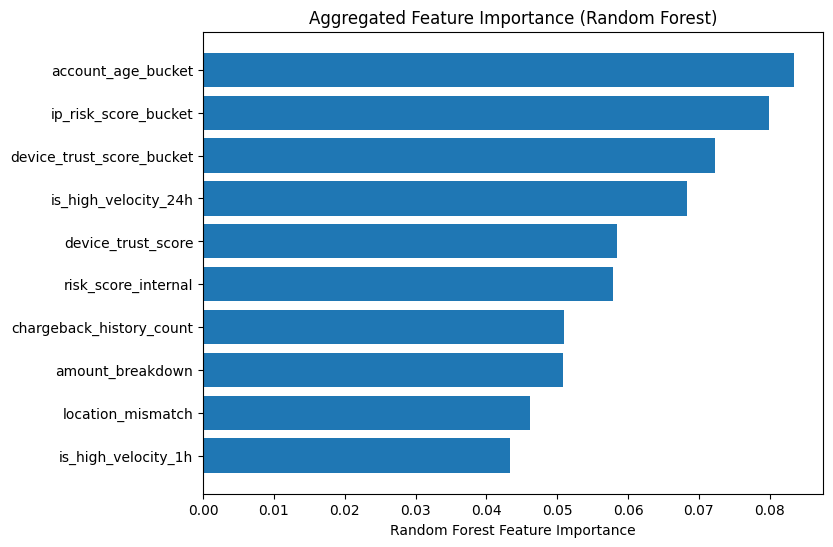

In [52]:
import matplotlib.pyplot as plt

top_rf = rf_aggregated_importance.head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_rf['original_feature'], top_rf['importance'])
plt.xlabel('Random Forest Feature Importance')
plt.title('Aggregated Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.show()


### XGBoost Feature Importance

In [53]:
import shap

explainer = shap.TreeExplainer(xgb_model)


In [54]:
shap_values = explainer.shap_values(X_test_preprocessed)


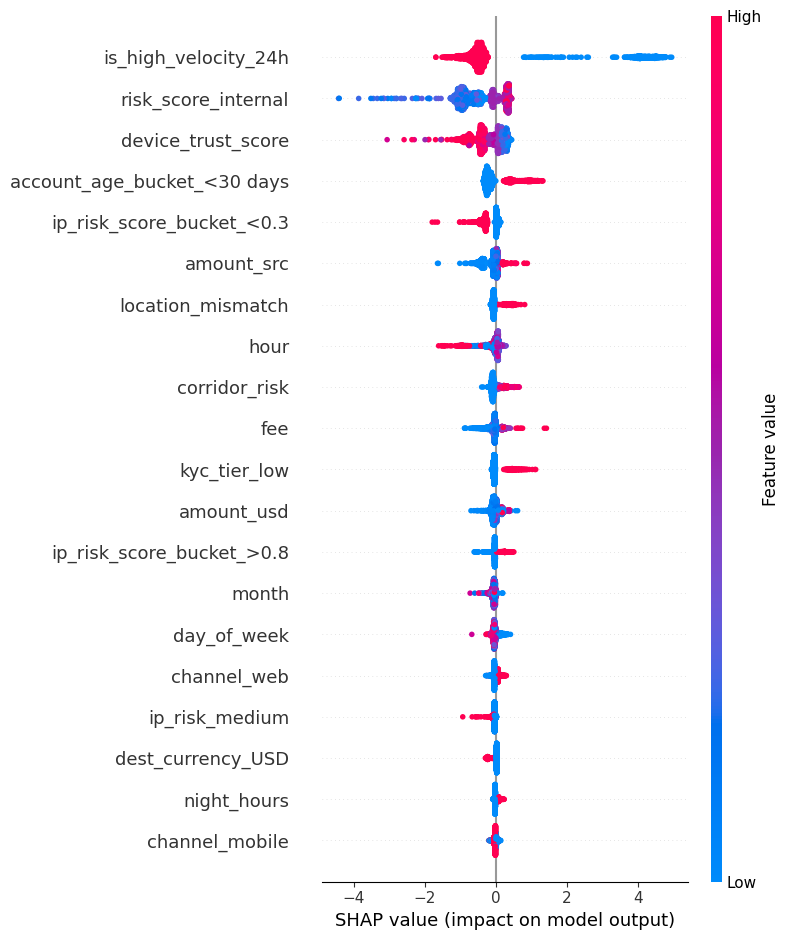

In [55]:
shap.summary_plot(
    shap_values,
    X_test_preprocessed,
    feature_names=encoded_features
)


# Advanced Modeling & Imbalance Handling

## Tuning XGBoost and LightGBM Models

In [115]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'scale_pos_weight': [scale_pos_w * 0.25, scale_pos_w * 0.5, scale_pos_w, scale_pos_w * 2]

}

xgb_tuned = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    scoring='average_precision',
    n_iter=25,
    cv=3,
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(X_train_preprocessed, y_train)

print("Best Parameters:", xgb_tuned.best_params_)
print("Best Score:", xgb_tuned.best_score_)

Best Parameters: {'subsample': 0.8, 'scale_pos_weight': np.float64(23.496296296296297), 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best Score: 0.8503103107956037


In [110]:
results_df = pd.DataFrame(xgb_tuned.cv_results_)
results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_scale_pos_weight,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,80.276420,12.369672,0.303003,0.044277,1.0,11.748148,200,10,6,0.20,0.8,"{'subsample': 1.0, 'scale_pos_weight': 11.7481...",0.853061,0.949485,0.952549,0.918365,0.046194,22
1,92.911740,21.138834,0.217154,0.026053,0.9,23.496296,200,10,10,0.01,0.9,"{'subsample': 0.9, 'scale_pos_weight': 23.4962...",0.857897,0.965055,0.956139,0.926364,0.048550,10
2,48.814388,14.219067,0.276836,0.110338,1.0,2.937037,100,5,6,0.01,0.9,"{'subsample': 1.0, 'scale_pos_weight': 2.93703...",0.868586,0.973587,0.961928,0.934701,0.046991,2
3,31.767643,2.287145,0.252735,0.076268,0.8,5.874074,100,1,6,0.01,0.9,"{'subsample': 0.8, 'scale_pos_weight': 5.87407...",0.843012,0.976190,0.961297,0.926833,0.059581,9
4,24.243024,0.501887,0.225613,0.071003,0.8,11.748148,100,1,3,0.20,0.9,"{'subsample': 0.8, 'scale_pos_weight': 11.7481...",0.856469,0.957143,0.957928,0.923847,0.047644,14


In [111]:
params_df = results_df['params'].apply(pd.Series)

log_df = pd.concat(
    [
        params_df,
        results_df[
            ['mean_test_score', 'std_test_score', 'rank_test_score']
        ]
    ],
    axis=1
)


In [112]:
log_df = log_df.rename(columns={
    'mean_test_score': 'cv_roc_auc_mean',
    'std_test_score': 'cv_roc_auc_std',
    'rank_test_score': 'cv_rank'
})


In [113]:
log_df = log_df.sort_values('cv_rank')


In [114]:
log_df.to_csv("xgb_hyperparameter_tuning_log.csv", index=False)


In [61]:
param_dist_lgbm = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_child_samples': [5, 10, 20],
    'subsample': [0.5, 0.8, 1.0],
    'feature_fraction': [0.8, 1.0],

    'scale_pos_weight': [scale_pos_w * 0.25, scale_pos_w * 0.5, scale_pos_w, scale_pos_w * 2]

}

In [65]:
print([scale_pos_w * 0.25, scale_pos_w * 0.5, scale_pos_w, scale_pos_w * 2])

[np.float64(2.937037037037037), np.float64(5.874074074074074), np.float64(11.748148148148148), np.float64(23.496296296296297)]


In [64]:
lgbm_tuned = RandomizedSearchCV(
    estimator=lgbm_model,
    scoring='average_precision',
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1
)

lgbm_tuned.fit(X_train_preprocessed, y_train)

RandomizedSearchCV(cv=5,
                   estimator=LGBMClassifier(class_weight='balanced',
                                            max_depth=6, random_state=42,
                                            verbosity=-1),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 6, 10],
                                        'min_child_weight': [1, 5, 10],
                                        'n_estimators': [50, 100, 200],
                                        'scale_pos_weight': [np.float64(2.937037037037037),
                                                             np.float64(5.874074074074074),
                                                             np.float64(11.748148148148148),
                                                             np.float64(23.496296296296297)],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42)

In [116]:
tuned_xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.01,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_w * 2,
    random_state=42,
    eval_metric='logloss'
    )

tuned_xgb_model.fit(X_train_preprocessed, y_train)
y_proba_tuned_xgb_model = tuned_xgb_model.predict_proba(X_test_preprocessed)[:, 1]




In [124]:
threshold = 0.7
y_pred_t = (y_proba_tuned_xgb_model >= threshold).astype(int)
print(classification_report(y_test, y_pred_t))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       0.99      0.93      0.96       307

    accuracy                           0.99      2152
   macro avg       0.99      0.96      0.97      2152
weighted avg       0.99      0.99      0.99      2152



In [68]:
tuned_lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.2,
    class_weight='balanced',
    verbosity=-1,
    random_state=42,
    colsample_bytree=0.8,
    min_child_weight=10,
    scale_pos_weight=scale_pos_w
    )

tuned_lgbm_model.fit(X_train_preprocessed, y_train)
y_proba_tuned_lgbm_model = tuned_lgbm_model.predict_proba(X_test_preprocessed)[:, 1]



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [125]:
y_pred_t = (y_proba_tuned_lgbm_model >= threshold).astype(int)
print(classification_report(y_test, y_pred_t))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1845
           1       0.93      0.93      0.93       307

    accuracy                           0.98      2152
   macro avg       0.96      0.96      0.96      2152
weighted avg       0.98      0.98      0.98      2152



## Further Experimentation

### SMOTE

In [130]:
from imblearn.over_sampling import SMOTE

sampling_grid = [0.1, 0.2, 0.3, 0.5]
smote_results = []


In [131]:
for ratio in sampling_grid:
    smote = SMOTE(
        sampling_strategy=ratio,
        k_neighbors=5,
        random_state=42
    )

    X_train_smote, y_train_smote = smote.fit_resample(
        X_train_preprocessed,
        y_train
    )

    xgb_model = XGBClassifier(
      n_estimators=100,
      max_depth=3,
      learning_rate=0.01,
      min_child_weight=1,
      subsample=0.8,
      colsample_bytree=0.8,
      scale_pos_weight=scale_pos_w * 2,
      random_state=42,
      eval_metric='logloss'
      )

    # xgb_model = XGBClassifier(
    #     n_estimators=100,
    #     max_depth=6,
    #     learning_rate=0.1,
    #     scale_pos_weight=scale_pos_w,
    #     random_state=42,
    #     eval_metric='logloss'
    #     )

    xgb_model.fit(X_train_smote, y_train_smote)

    y_proba_smote_xgb_model = xgb_model.predict_proba(X_test_preprocessed)[:, 1]

    y_pred_t = (y_proba_smote_xgb_model >= threshold).astype(int)

    smote_results.append({
        'sampling_ratio': ratio,
        'classification_report': classification_report(y_test, y_pred_t)
    })

In [132]:
for result in smote_results:
    print(f"Sampling Ratio: {result['sampling_ratio']}")
    print(result['classification_report'])
    print("-" * 50)

Sampling Ratio: 0.1
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       0.98      0.93      0.95       307

    accuracy                           0.99      2152
   macro avg       0.98      0.96      0.97      2152
weighted avg       0.99      0.99      0.99      2152

--------------------------------------------------
Sampling Ratio: 0.2
              precision    recall  f1-score   support

           0       0.99      0.92      0.95      1845
           1       0.66      0.95      0.78       307

    accuracy                           0.92      2152
   macro avg       0.83      0.94      0.87      2152
weighted avg       0.94      0.92      0.93      2152

--------------------------------------------------
Sampling Ratio: 0.3
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      1845
           1       0.61      0.96      0.74       307

    accuracy        

In [133]:
smote = SMOTE(
        sampling_strategy=0.1,
        k_neighbors=5,
        random_state=42
    )

X_train_smote, y_train_smote = smote.fit_resample(
  X_train_preprocessed,
  y_train
)

smote_xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_w,
    random_state=42,
    eval_metric='logloss'
    )

smote_xgb_model.fit(X_train_smote, y_train_smote)
y_proba_smote_xgb_model = smote_xgb_model.predict_proba(X_test_preprocessed)[:, 1]

In [134]:
y_pred_t = (y_proba_smote_xgb_model >= threshold).astype(int)
print(classification_report(y_test, y_pred_t))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       0.99      0.93      0.96       307

    accuracy                           0.99      2152
   macro avg       0.99      0.96      0.97      2152
weighted avg       0.99      0.99      0.99      2152



In [135]:
smote_lgbm_results = []

for ratio in sampling_grid:
    smote = SMOTE(
        sampling_strategy=ratio,
        k_neighbors=5,
        random_state=42
    )

    X_train_smote, y_train_smote = smote.fit_resample(
        X_train_preprocessed,
        y_train
    )

    lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    verbosity=-1,
    random_state=42,
    )

    lgbm_model.fit(X_train_smote, y_train_smote)

    y_proba_smote_lgbm_model = lgbm_model.predict_proba(X_test_preprocessed)[:, 1]

    y_pred_t = (y_proba_smote_lgbm_model >= threshold).astype(int)

    smote_lgbm_results.append({
        'sampling_ratio': ratio,
        'classification_report': classification_report(y_test, y_pred_t)
    })

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [136]:
for result in smote_lgbm_results:
    print(f"Sampling Ratio: {result['sampling_ratio']}")
    print(result['classification_report'])
    print("-" * 50)

Sampling Ratio: 0.1
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       0.99      0.92      0.95       307

    accuracy                           0.99      2152
   macro avg       0.99      0.96      0.97      2152
weighted avg       0.99      0.99      0.99      2152

--------------------------------------------------
Sampling Ratio: 0.2
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       1.00      0.92      0.96       307

    accuracy                           0.99      2152
   macro avg       0.99      0.96      0.98      2152
weighted avg       0.99      0.99      0.99      2152

--------------------------------------------------
Sampling Ratio: 0.3
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       1.00      0.92      0.96       307

    accuracy        

In [103]:
smote = SMOTE(
        sampling_strategy=0.5,
        k_neighbors=5,
        random_state=42
    )

X_train_smote, y_train_smote = smote.fit_resample(
  X_train_preprocessed,
  y_train
)

smote_lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_w,
    random_state=42,
    eval_metric='logloss'
    )

smote_lgbm_model.fit(X_train_smote, y_train_smote)
y_proba_smote_lgbm_model = smote_lgbm_model.predict_proba(X_test_preprocessed)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [102]:
y_pred_t = (y_proba_smote_lgbm_model >= threshold).astype(int)
print(classification_report(y_test, y_pred_t))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       1.00      0.92      0.96       307

    accuracy                           0.99      2152
   macro avg       0.99      0.96      0.98      2152
weighted avg       0.99      0.99      0.99      2152



### Under-sampling

In [104]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

xgb_under_sampling_results = []

for ratio in sampling_grid:
    rus = RandomUnderSampler(
        sampling_strategy=ratio,
        random_state=42
    )

    X_under, y_under = rus.fit_resample(
        X_train_preprocessed,
        y_train
    )

    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_w,
        random_state=42,
        eval_metric='logloss'
        )

    xgb_model.fit(X_under, y_under)
    xgb_model.fit(X_under, y_under)

    y_prob = xgb_model.predict_proba(X_test_preprocessed)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    xgb_under_sampling_results.append({
        'sampling_ratio': ratio,
        'classification_report': classification_report(y_test, y_pred)
    })

In [137]:
for result in xgb_under_sampling_results:
    print(f"Sampling Ratio: {result['sampling_ratio']}")
    print(result['classification_report'])
    print("-" * 50)

Sampling Ratio: 0.1
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1845
           1       0.96      0.92      0.94       307

    accuracy                           0.98      2152
   macro avg       0.97      0.96      0.96      2152
weighted avg       0.98      0.98      0.98      2152

--------------------------------------------------
Sampling Ratio: 0.2
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1845
           1       0.83      0.93      0.88       307

    accuracy                           0.96      2152
   macro avg       0.91      0.95      0.93      2152
weighted avg       0.97      0.96      0.96      2152

--------------------------------------------------
Sampling Ratio: 0.3
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1845
           1       0.74      0.94      0.83       307

    accuracy        

In [138]:
lgbm_under_sampling_results = []

for ratio in sampling_grid:
    rus = RandomUnderSampler(
        sampling_strategy=ratio,
        random_state=42
    )

    X_under, y_under = rus.fit_resample(
        X_train_preprocessed,
        y_train
    )

    lgbm_model = LGBMClassifier(
      n_estimators=100,
      max_depth=6,
      learning_rate=0.1,
      class_weight='balanced',
      verbosity=-1,
      random_state=42,
      )

    lgbm_model.fit(X_under, y_under)
    lgbm_model.fit(X_under, y_under)

    y_prob = lgbm_model.predict_proba(X_test_preprocessed)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    lgbm_under_sampling_results.append({
        'sampling_ratio': ratio,
        'classification_report': classification_report(y_test, y_pred)
    })

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [139]:
for result in lgbm_under_sampling_results:
    print(f"Sampling Ratio: {result['sampling_ratio']}")
    print(result['classification_report'])
    print("-" * 50)

Sampling Ratio: 0.1
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       1.00      0.92      0.96       307

    accuracy                           0.99      2152
   macro avg       0.99      0.96      0.98      2152
weighted avg       0.99      0.99      0.99      2152

--------------------------------------------------
Sampling Ratio: 0.2
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       0.99      0.93      0.96       307

    accuracy                           0.99      2152
   macro avg       0.99      0.96      0.98      2152
weighted avg       0.99      0.99      0.99      2152

--------------------------------------------------
Sampling Ratio: 0.3
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       0.98      0.93      0.95       307

    accuracy        

# Experiment Logs

## SMOTE Logs

### SMOTE & Undersampling Experiments — XGBoost (k=5, threshold=0.7) | LGBM (threshold=0.7)



| Model | Sampling Strategy | Sampling Ratio | Precision (Fraud) | Recall (Fraud) | F1 (Fraud) | Accuracy | Decision | Notes | |
|------|------------------|----------------|-------------------|----------------|------------|----------|-----|----------|------|
| XGB | SMOTE | 0.1 | 0.98 | 0.93 | 0.95 | 0.99 | Keep (Exploratory) | Best SMOTE trade-off |
| XGB | SMOTE | 0.2 | 0.66 | 0.95 | 0.78 | 0.92 |  Reject | Precision collapse |
| XGB | SMOTE | 0.3 | 0.61 | 0.96 | 0.74 | 0.91 |  Reject | Excess false positives |
| XGB | SMOTE | 0.5 | 0.38 | 0.97 | 0.54 | 0.77 |  Reject | Severe degradation |
| LGBM | SMOTE | 0.1 | 0.99 | 0.92 | 0.95 | 0.99 |  Keep (Exploratory) | Stable but no recall gain |
| LGBM | SMOTE | 0.2 | 1.00 | 0.92 | 0.96 | 0.99 |  Reject | No improvement over 0.1 |
| LGBM | SMOTE | 0.3 | 1.00 | 0.92 | 0.96 | 0.99 |  Reject | Performance plateau |
| LGBM | SMOTE | 0.5 | 1.00 | 0.92 | 0.96 | 0.99 |  Reject | Overconfidence risk |
| XGB | Undersampling | 0.1 | 0.96 | 0.92 | 0.94 | 0.98 |  Keep (Exploratory) | Least harmful undersampling |
| XGB | Undersampling | 0.2 | 0.83 | 0.93 | 0.88 | 0.96 |  Reject | Precision drops |
| XGB | Undersampling | 0.3 | 0.74 | 0.94 | 0.83 | 0.94 |  Reject | Majority signal loss |
| XGB | Undersampling | 0.5 | 0.65 | 0.94 | 0.77 | 0.92 |  Reject | Severe instability |
| LGBM | Undersampling | 0.1 | 1.00 | 0.92 | 0.96 | 0.99 |  Keep (Exploratory) | Very stable |
| LGBM | Undersampling | 0.2 | 0.99 | 0.93 | 0.96 | 0.99 |  Keep (Exploratory) | Slight recall gain |
| LGBM | Undersampling | 0.3 | 0.98 | 0.93 | 0.95 | 0.99 |  Reject | No added benefit |
| LGBM | Undersampling | 0.5 | 0.91 | 0.93 | 0.92 | 0.98 |  Reject | Precision erosion |


